In [1]:
from ppg_basis import ppgGenerator
from ppg_basis import ppgExtractor
import matplotlib.pyplot as plt

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),Radeon 8060S Graphics (RADV GFX1151),IntegratedGPU,Vulkan,Mesa 25.1.5-arch1.1
❌,"Radeon 8060S Graphics (radeonsi, gfx1151, LLVM 20.1.7, DRM 3.61, 6.12.38-1-MANJARO)",Unknown,OpenGL,4.6 (Core Profile) Mesa 25.1.5-arch1.1


Text(0.5, 1.0, 'Original PPG')

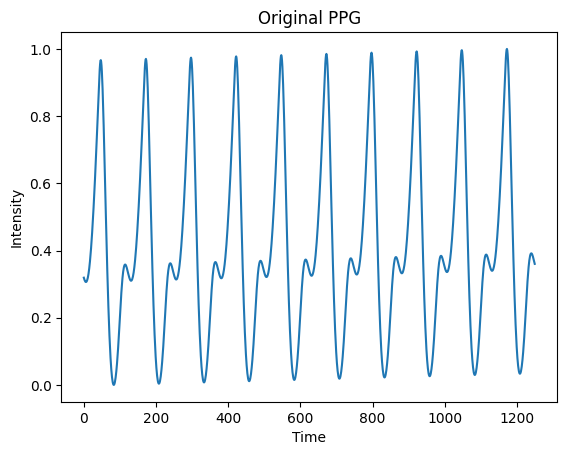

In [2]:
# Generate signal
ppgGen = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma")

sig = ppgGen.generate_signal()
plt.plot(sig)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original PPG")

In [3]:
# Extract signal parameters
ppgExt = ppgExtractor(signal=sig,
                      fs=125,
                      hr=60,
                      sigma=0,
                      L=3,
                      basis_type='gamma')

views = ppgExt.plot_cost_landscape(mse_flag=True,
                                    corr_flag=True,
                                    appg_flag=False)

Basis 1/3


RFBOutputContext()

/home/aju/mabos/lib/python3.13/site-packages/pygfx/objects/_ruler.py:270: RuntimeWarning: divide by zero encountered in divide
  screen_full = (ndc_full[:, :2] / ndc_full[:, 3:4]) * half_canvas_size
/home/aju/mabos/lib/python3.13/site-packages/pygfx/objects/_ruler.py:270: RuntimeWarning: invalid value encountered in divide
  screen_full = (ndc_full[:, :2] / ndc_full[:, 3:4]) * half_canvas_size
/home/aju/mabos/lib/python3.13/site-packages/pygfx/objects/_ruler.py:282: RuntimeWarning: invalid value encountered in divide
  screen_sel = (ndc_sel[:, :2] / ndc_sel[:, 3:4]) * half_canvas_size
/home/aju/mabos/lib/python3.13/site-packages/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


Basis 2/3


RFBOutputContext()

Basis 3/3


RFBOutputContext()

In [4]:
for v in views:
    display(v)

In [5]:
ppgExt.mse_flag = True
ppgExt.corr_flag = True
ppgExt.appg_flag = False
theta_pred, params_pred = ppgExt.extract_ppg(block_update=True, 
                                             coord_cycles=4)

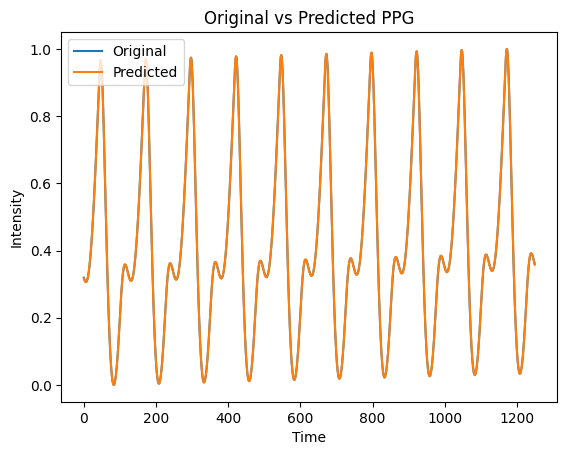

In [6]:
# Generate PPG using extracted parameters
ppgPrd = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      thetas=theta_pred,
                      params=params_pred)
pred = ppgPrd.generate_signal()

plt.plot(sig)
plt.plot(pred)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original vs Predicted PPG")
plt.legend(["Original", "Predicted"])

In [7]:
# Fig. 4: Show utility in phase extraction and data augmentation
# Later part of paper could argue about augmentated trial datasets, and use for future ML
# Noise resistance models w/ DNNs
# Check comparision w/ PPGSynth and Other stateof the art methods
# Message tano and get access to PPG data